Notebook

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [2]:
# Load Rock-Paper-Scissors dataset
dataset_name = "rock_paper_scissors"
(train_ds, val_ds), ds_info = tfds.load(dataset_name, split=['train', 'test'], as_supervised=True, with_info=True)
print(f"Dataset loaded: {dataset_name}")
print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/2520 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.63WVOM_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...:   0%|          | 0/372 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.63WVOM_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.
Dataset loaded: rock_paper_scissors
tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    full_name='rock_paper_scissors/3.0.0',
    description="""
    Images of hands playing rock, paper, scissor game.
    """,
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    data_dir=PosixGPath('/tmp/tmp63zklk44tfds'),
    file_format=tfrecord,
    download_size=219.53 MiB,
    dataset_size=219.23 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'test': <SplitInfo num_examples=372, num_shards=1>,
        'train': <SplitInfo num_examples=2520, num_shards=2>,
    },
    citation="""@ONLINE {rps,
    author = "Laurence Moron

In [3]:
# Preprocess the data
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE) / 255.0  # Normalize
    return image, label

train_ds = train_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [29]:
# Function to build and train models
def build_and_train_model(base_model, model_name, trainable_layers=0, num_epochs=5):
    base_model.trainable = False  # Freeze base model by default
    if trainable_layers > 0:
        for layer in base_model.layers[-trainable_layers:]:
            layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(3, activation='softmax')(x)
    model = Model(inputs=base_model.input,
                  outputs=predictions)

    model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(train_ds, validation_data=val_ds, epochs=num_epochs)

    # Plot training history
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.legend()
    plt.show()

    # Make predictions on validation set
    predictions = model.predict(val_ds)
    predicted_labels = tf.argmax(predictions, axis=1)

    # # Print some predictions
    # print("Sample Predictions:")
    # for i in range(5):  # Print predictions for the first 5 images
    #     print(f"Image {i + 1}: Predicted Label: {predicted_labels[i].numpy()}, True Label: {val_ds.unbatch().element_spec[1].dtype.as_numpy_dtype(val_ds.unbatch().as_numpy_iterator().__next__()[1])}")

    # Display images with predictions
    print("Sample Predictions:")
    indices = [1, 50, 100, 150, 200, 250]  # Define the desired indices
    for i in indices:  # Display predictions for specified indices
        image, true_label = next(iter(val_ds.unbatch().skip(i - 1).take(1).as_numpy_iterator()))
        plt.imshow(image)
        plt.title(f"Predicted: {predicted_labels[i-1].numpy()}, True: {true_label}")
        plt.show()

    return history

Training MobileNetV2 with frozen layers
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.5427 - loss: 0.9678 - val_accuracy: 0.8737 - val_loss: 0.4826
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9401 - loss: 0.2282 - val_accuracy: 0.9113 - val_loss: 0.3381
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9784 - loss: 0.1203 - val_accuracy: 0.9355 - val_loss: 0.2586
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9932 - loss: 0.0671 - val_accuracy: 0.9301 - val_loss: 0.2392
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9944 - loss: 0.0521 - val_accuracy: 0.9301 - val_loss: 0.2300


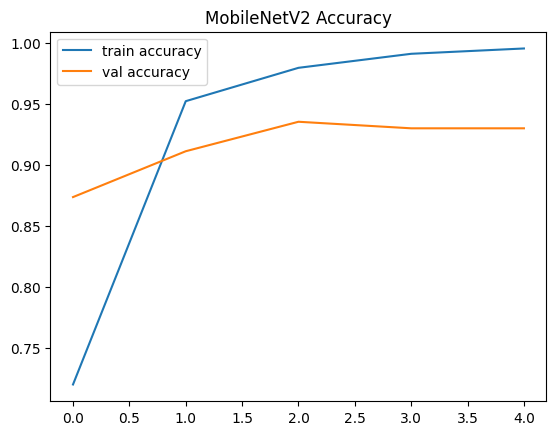

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 341ms/step
Sample Predictions:


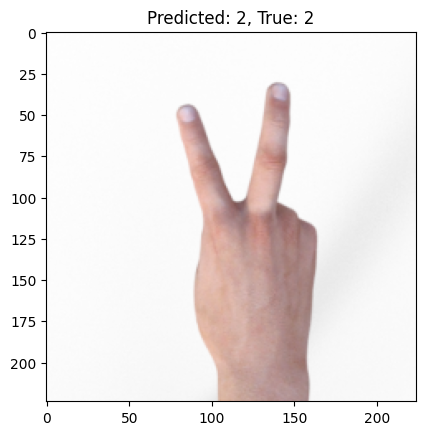

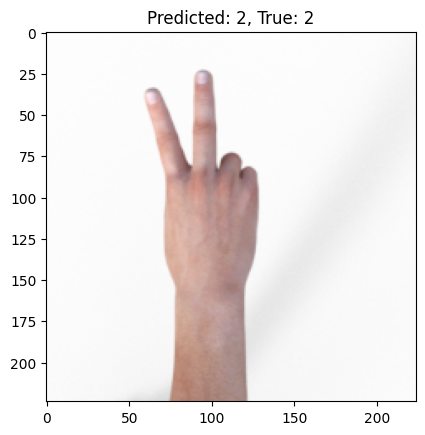

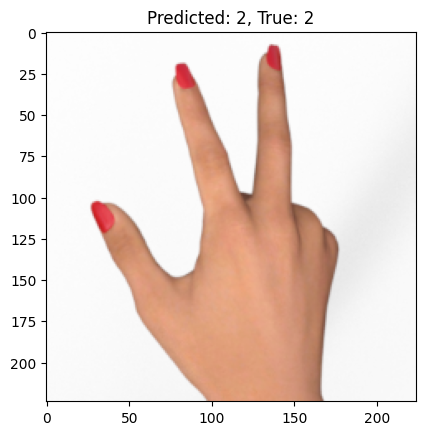

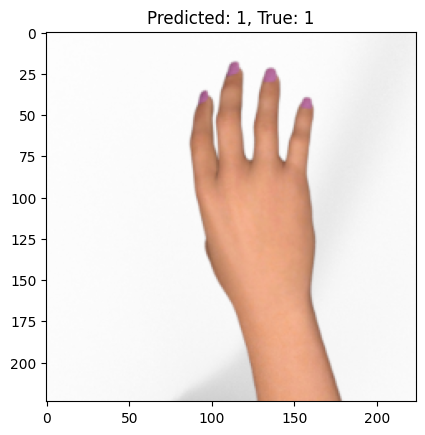

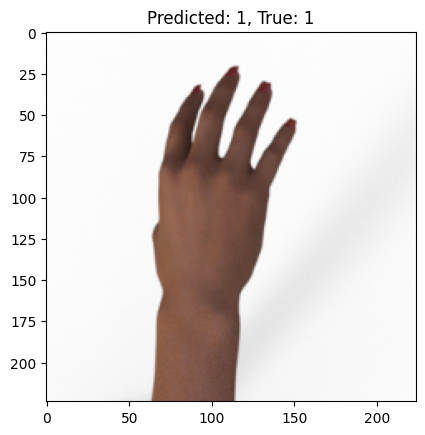

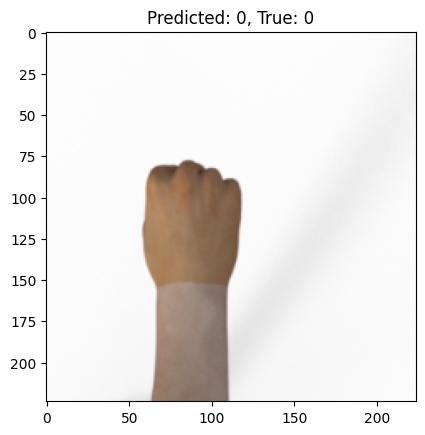

Training MobileNetV2 with trainable layers
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 180ms/step - accuracy: 0.8711 - loss: 0.3151 - val_accuracy: 0.6102 - val_loss: 2.3599
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 0.6505 - val_loss: 2.4608
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.6640 - val_loss: 2.2472
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9986 - loss: 0.0023 - val_accuracy: 0.6882 - val_loss: 1.8341
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 1.0000 - loss: 8.2561e-04 - val_accuracy: 0.7070 - val_loss: 1.7105


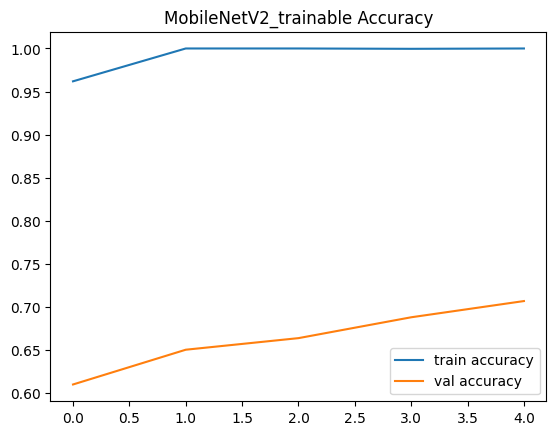

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step
Sample Predictions:


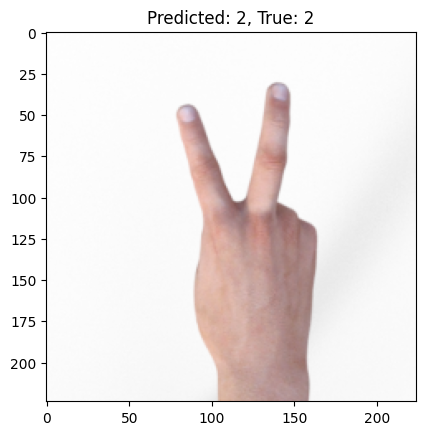

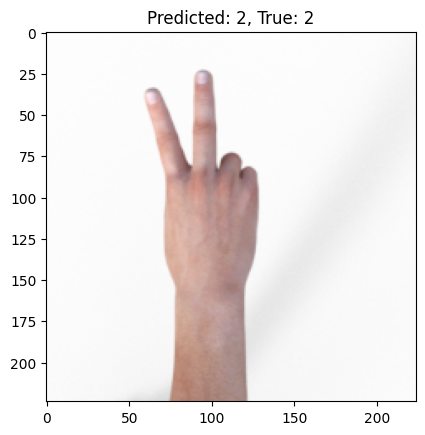

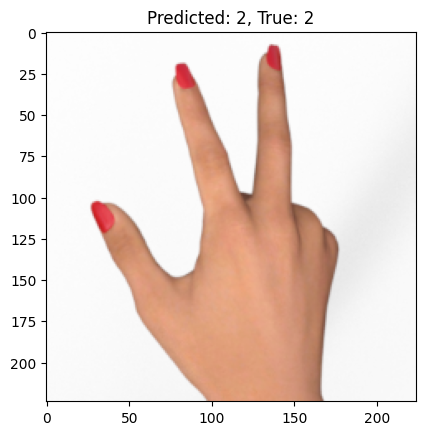

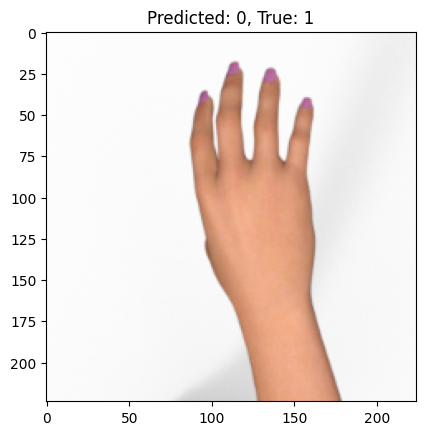

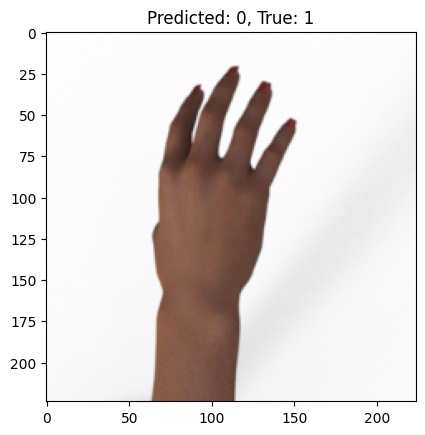

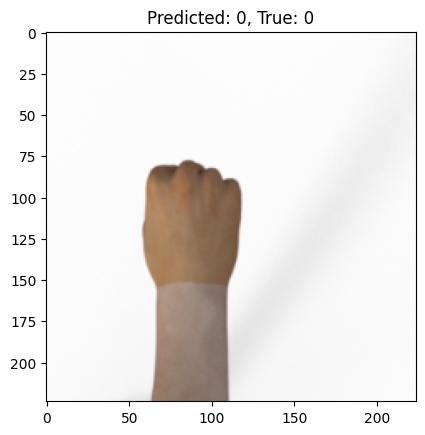

Training ResNet50 with frozen layers
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 201ms/step - accuracy: 0.3629 - loss: 1.2203 - val_accuracy: 0.4328 - val_loss: 1.0372
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.4911 - loss: 1.0106 - val_accuracy: 0.5000 - val_loss: 1.0029
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.6328 - loss: 0.9114 - val_accuracy: 0.5242 - val_loss: 0.9731
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.6629 - loss: 0.8520 - val_accuracy: 0.6344 - val_loss: 0.9435
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.7180 - loss: 0.7948 - val_accuracy: 0.6613 - val_loss: 0.9158


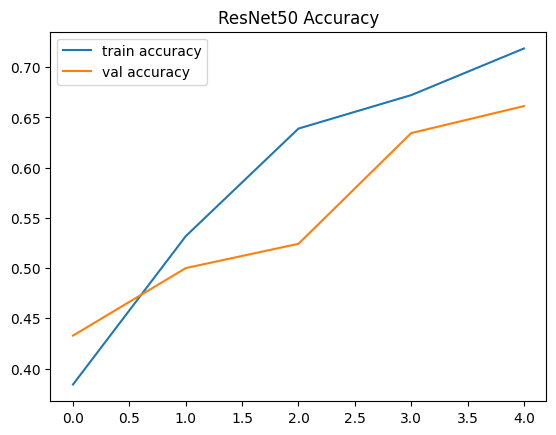

12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 411ms/step
Sample Predictions:


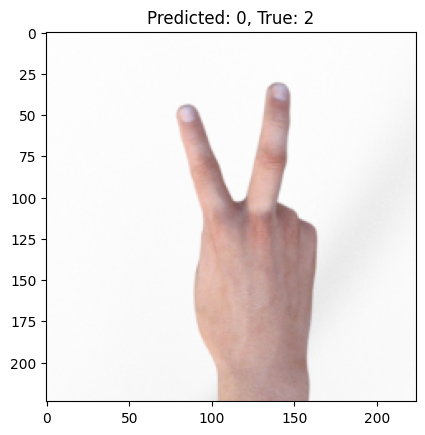

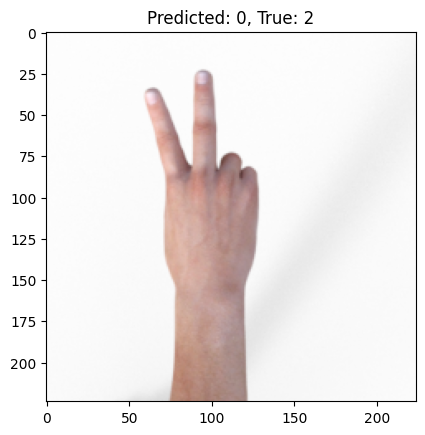

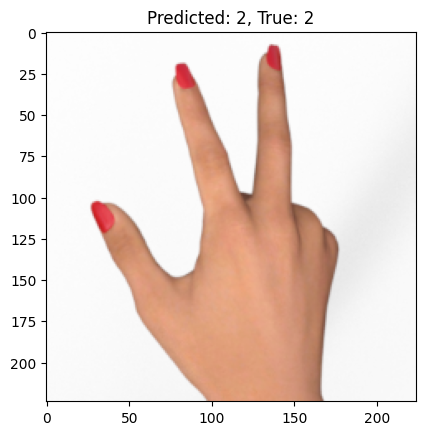

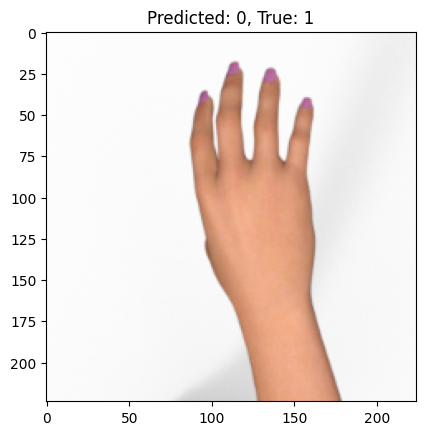

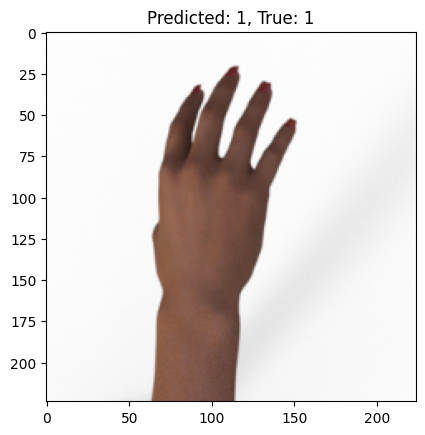

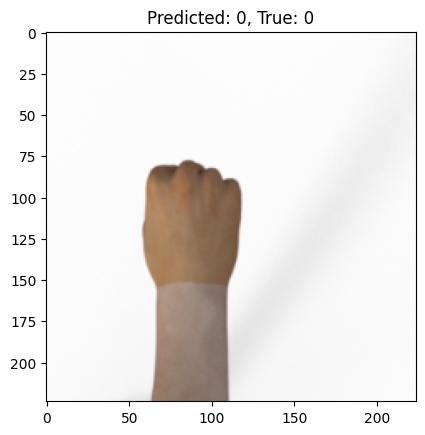

Training ResNet50 with trainable layers
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 267ms/step - accuracy: 0.8685 - loss: 0.3494 - val_accuracy: 0.3333 - val_loss: 1.6648
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 24s 122ms/step - accuracy: 0.9849 - loss: 0.0489 - val_accuracy: 0.3333 - val_loss: 1.4846
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.9904 - loss: 0.0280 - val_accuracy: 0.7258 - val_loss: 0.6214
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.9936 - loss: 0.0186 - val_accuracy: 0.5108 - val_loss: 1.5433
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.9977 - loss: 0.0098 - val_accuracy: 0.8898 - val_loss: 0.3444


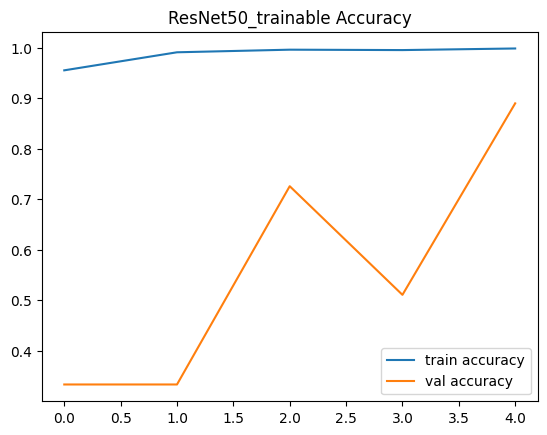

12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 403ms/step
Sample Predictions:


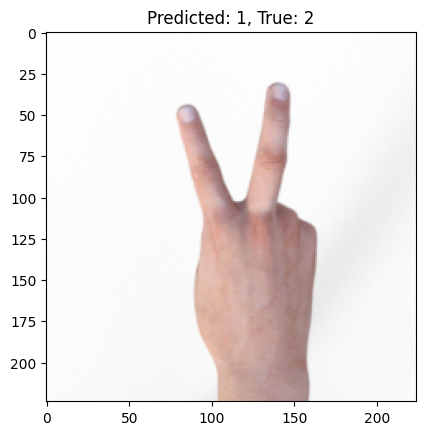

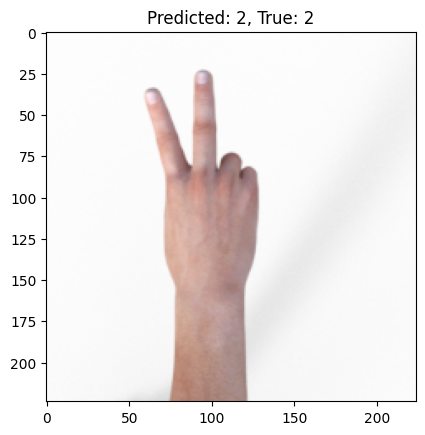

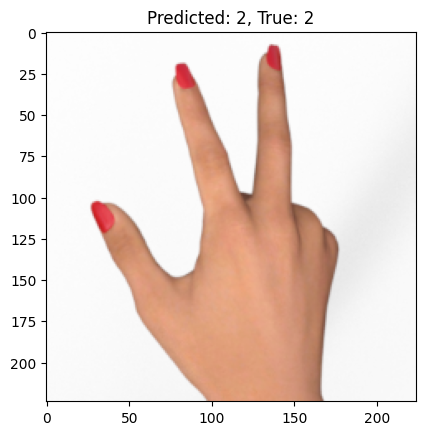

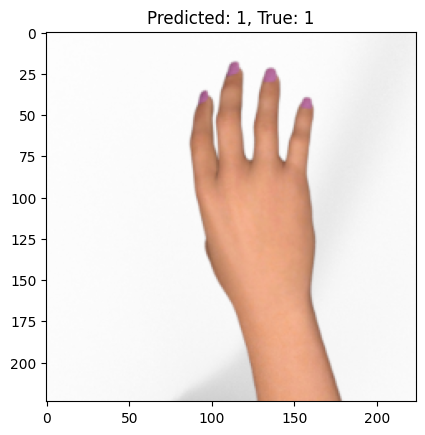

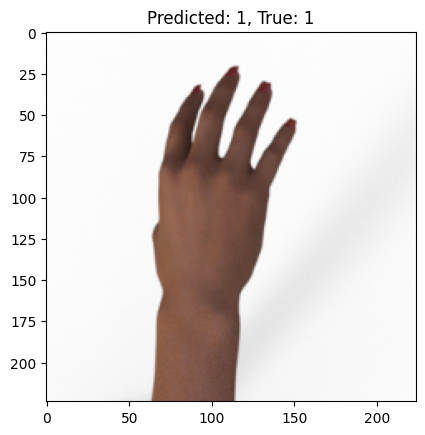

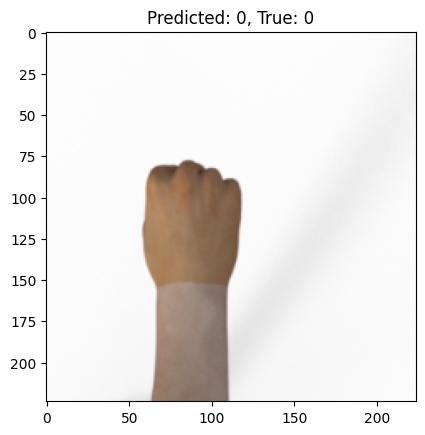

Training EfficientNetB0 with frozen layers
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 262ms/step - accuracy: 0.3637 - loss: 1.1066 - val_accuracy: 0.3333 - val_loss: 1.1010
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3240 - loss: 1.1104 - val_accuracy: 0.3333 - val_loss: 1.1012
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.3317 - loss: 1.1037 - val_accuracy: 0.3333 - val_loss: 1.0998
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.3273 - loss: 1.1021 - val_accuracy: 0.3333 - val_loss: 1.0991
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.3238 - loss: 1.1036 - val_accuracy: 0.3333 - val_loss: 1.0987


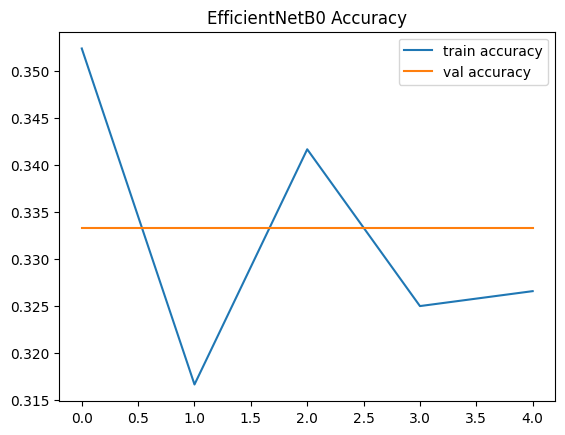

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 627ms/step
Sample Predictions:


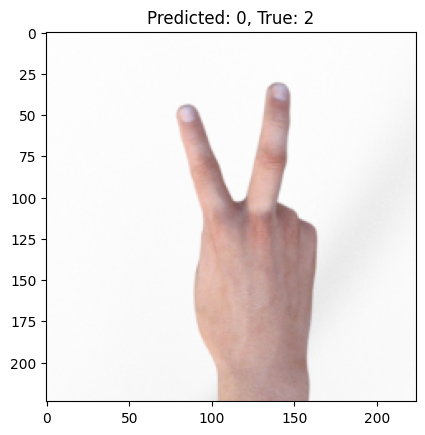

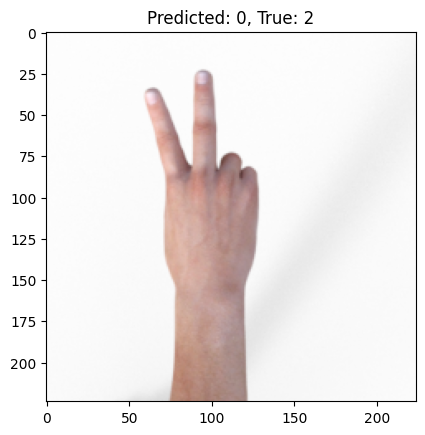

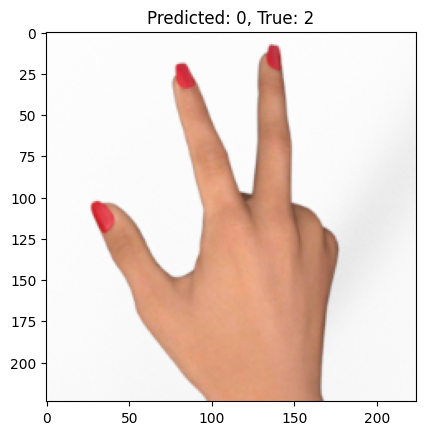

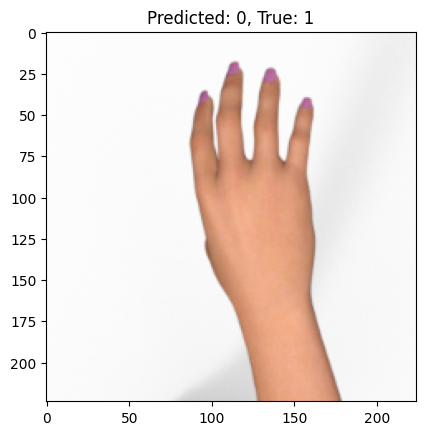

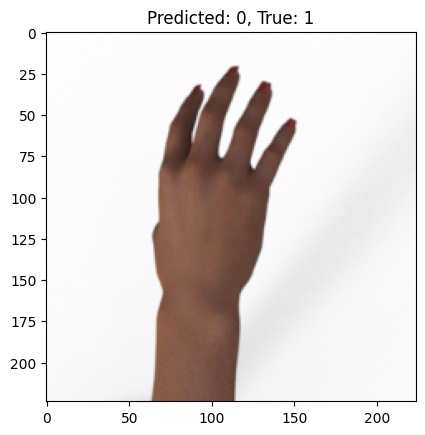

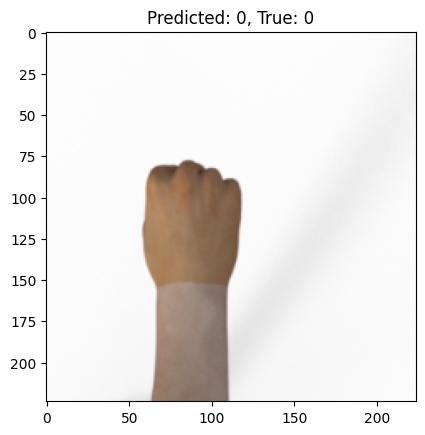

Training EfficientNetB0 with trainable layers
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 313ms/step - accuracy: 0.3281 - loss: 1.1267 - val_accuracy: 0.3333 - val_loss: 1.1025
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.3539 - loss: 1.1103 - val_accuracy: 0.3333 - val_loss: 1.0990
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.3454 - loss: 1.1054 - val_accuracy: 0.3333 - val_loss: 1.0979
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.3624 - loss: 1.0914 - val_accuracy: 0.3952 - val_loss: 1.0911
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.3907 - loss: 1.0795 - val_accuracy: 0.3333 - val_loss: 1.1073


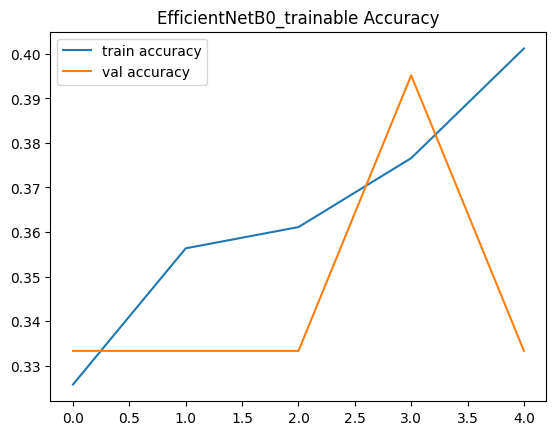

12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 579ms/step
Sample Predictions:


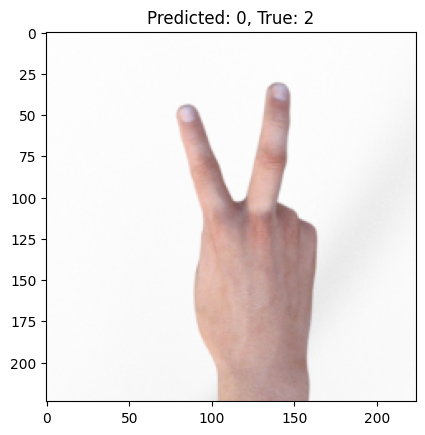

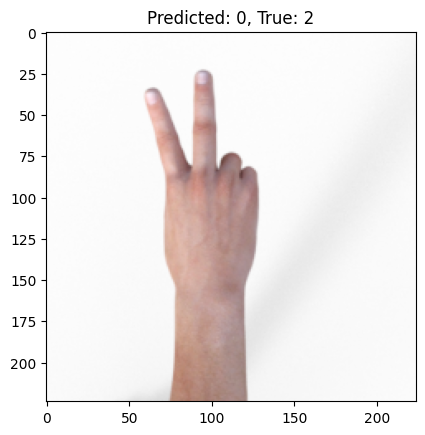

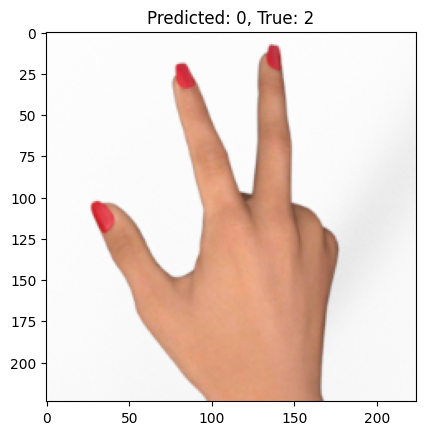

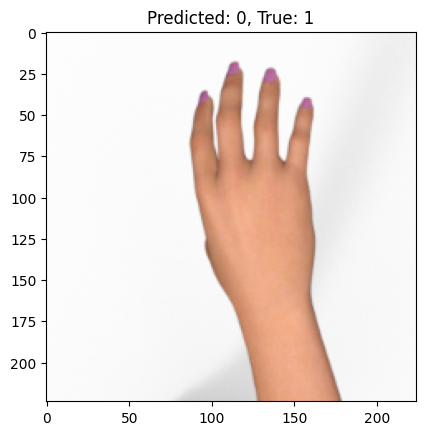

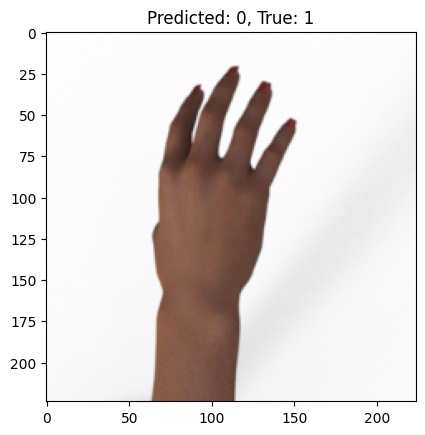

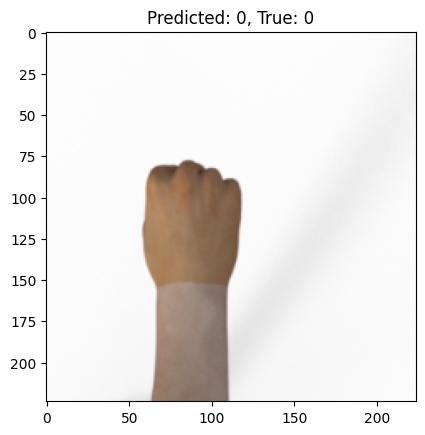

Training complete!


In [30]:
# Using MobileNetV2, ResNet50, and EfficientNetB0
base_models = {
    "MobileNetV2": MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    "ResNet50": ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    "EfficientNetB0": EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
}

results = {}
for model_name, base_model in base_models.items():
    print(f"Training {model_name} with frozen layers")
    results[model_name] = build_and_train_model(base_model, model_name)

    print(f"Training {model_name} with trainable layers")
    results[model_name + "_trainable"] = build_and_train_model(base_model, model_name + "_trainable", trainable_layers=20, num_epochs=5)

print("Training complete!")


In [ ]:
# Using MobileNetV2, ResNet50, and EfficientNetB0
base_models = {
    "MobileNetV2": MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    "ResNet50": ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    "EfficientNetB0": EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
}

results = {}
for model_name, base_model in base_models.items():
    print(f"Training {model_name} with trainable layers")
    results[model_name + "_trainable"] = build_and_train_model(base_model, model_name + "_trainable", trainable_layers=20, num_epochs=30)

print("Training complete!")


Training MobileNetV2 with trainable layers
Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8558 - loss: 0.3622

Training MobileNetV2 with trainable layers
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 159ms/step - accuracy: 0.8684 - loss: 0.3328 - val_accuracy: 0.6667 - val_loss: 1.5730


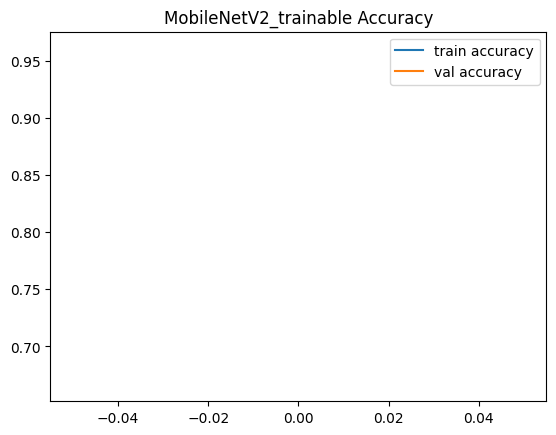

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 284ms/step
Sample Predictions:


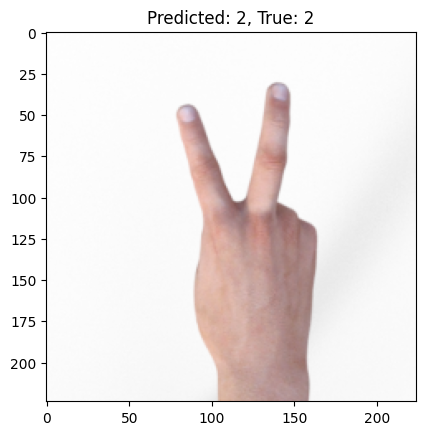

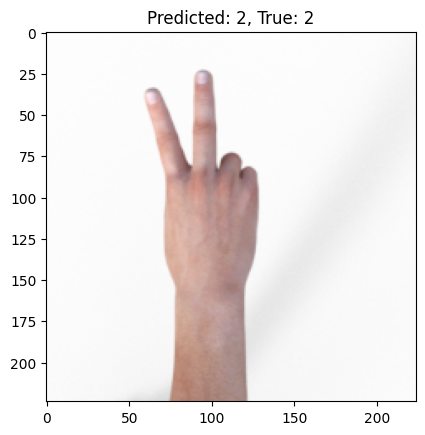

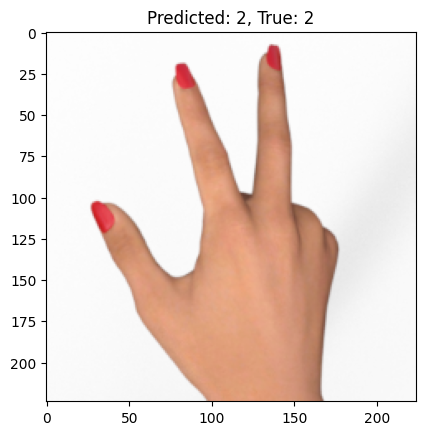

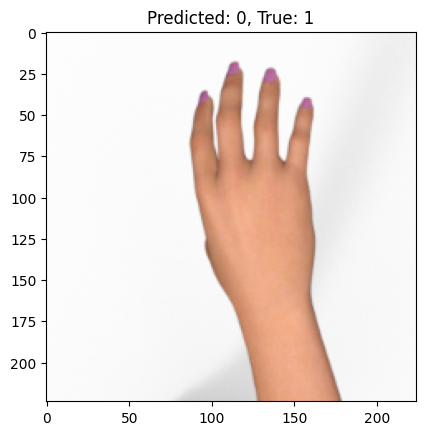

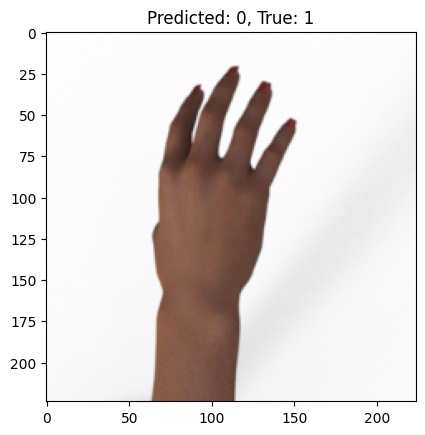

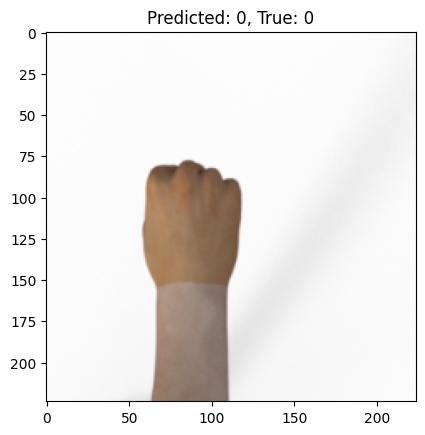

Training complete!


In [28]:
# Using MobileNetV2, ResNet50, and EfficientNetB0
base_models = {
    "MobileNetV2": MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
}

results_2 = {}
for model_name, base_model in base_models.items():
    # print(f"Training {model_name} with frozen layers")
    # results[model_name] = build_and_train_model(base_model, model_name)

    print(f"Training {model_name} with trainable layers")
    results_2[model_name + "_trainable"] = build_and_train_model(base_model, model_name + "_trainable", trainable_layers=20, num_epochs=1)

print("Training complete!")
